# Modern CNN Architectures: From ResNet to EfficientNet

## Mastering Deep Networks and Transfer Learning

---

In Part 1, we learned the fundamentals of CNNs. Now we dive into the **architectural innovations** that enabled training of extremely deep networks and achieving state-of-the-art performance.

### The Evolution of CNN Architectures

| Year | Architecture | Depth | Top-5 Error | Key Innovation |
|------|-------------|-------|-------------|---------------|
| 2012 | AlexNet | 8 | 16.4% | GPU training, ReLU, Dropout |
| 2014 | VGGNet | 19 | 7.3% | Small 3×3 filters throughout |
| 2014 | GoogLeNet | 22 | 6.7% | Inception modules (multi-scale) |
| 2015 | **ResNet** | 152 | 3.6% | Skip connections (residual learning) |
| 2017 | DenseNet | 201 | 3.5% | Dense connections |
| 2019 | **EfficientNet** | Variable | 2.9% | Compound scaling |
| 2021 | ConvNeXt | Variable | 2.2% | Modernized ResNet |

### What You'll Learn

| Chapter | Topic | Key Concepts |
|---------|-------|-------------|
| 1 | The Vanishing Gradient Problem | Why deep networks fail |
| 2 | ResNet & Skip Connections | Residual learning |
| 3 | Advanced Blocks | Bottleneck, SE, MBConv |
| 4 | EfficientNet | Compound scaling |
| 5 | Transfer Learning | Using pretrained models |
| 6 | Fine-Tuning Strategies | Adapting to new tasks |
| 7 | Real-World Application | Complete image classifier |

---

*"The residual connection is one of the most important innovations in deep learning."* - Yann LeCun

In [1]:
# ============================================================================
#                           SETUP & IMPORTS
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple, Optional, Callable
import warnings
warnings.filterwarnings('ignore')

# Beautiful plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PyTorch Version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


---

# Chapter 1: The Vanishing Gradient Problem

## Why Deeper Isn't Always Better

Before 2015, training very deep networks (>20 layers) was nearly impossible. The problem:

### The Math Behind Vanishing Gradients

During backpropagation, gradients are multiplied through layers:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial a_n} \cdot \frac{\partial a_n}{\partial a_{n-1}} \cdot ... \cdot \frac{\partial a_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial w_1}$$

If each gradient term is < 1 (like sigmoid derivative ≤ 0.25), then:
- 10 layers: $0.25^{10} \approx 10^{-6}$
- 50 layers: $0.25^{50} \approx 10^{-30}$ ← Effectively zero!

```
Layer 1  ←─── tiny gradient (vanishing)
   ↓
Layer 2  ←─── small gradient
   ↓
   ...
   ↓
Layer N  ←─── normal gradient
   ↓
 Loss
```

       VANISHING GRADIENT DEMONSTRATION


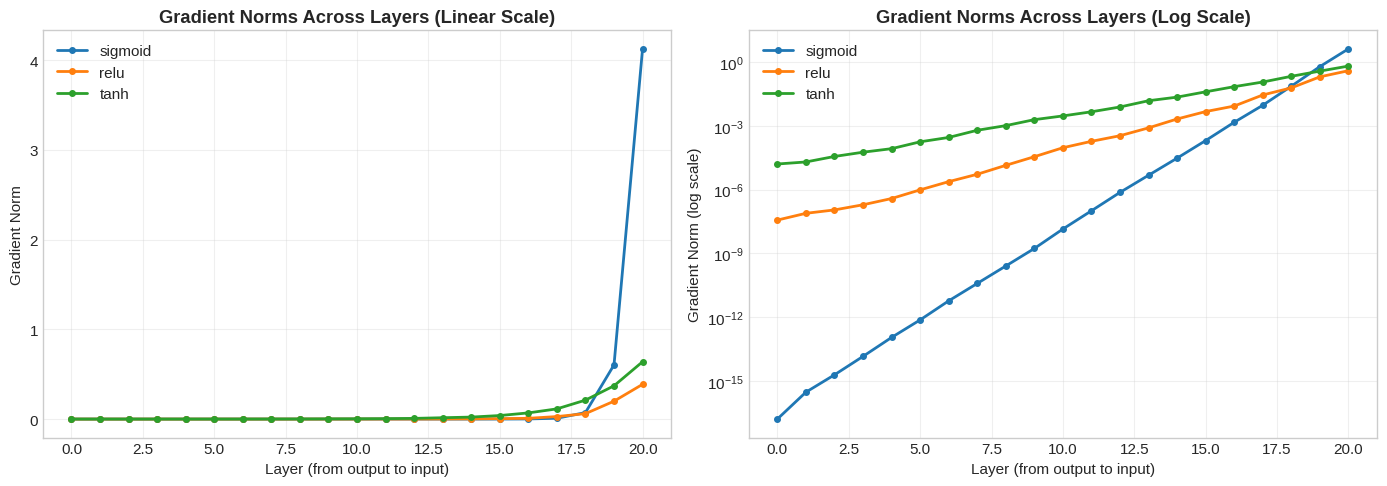


 Key Observations:
 - Sigmoid: Gradients vanish exponentially (unusable after ~10 layers)
 - Tanh: Better than sigmoid, but still vanishes
 - ReLU: Gradients remain stable (but can 'die')


In [2]:
# ============================================================================
#             DEMONSTRATING VANISHING GRADIENTS
# ============================================================================

print("="*60)
print("       VANISHING GRADIENT DEMONSTRATION")
print("="*60)

def create_deep_network(n_layers: int, activation: str = 'sigmoid') -> nn.Sequential:
    """
    Create a deep network to demonstrate vanishing gradients.
    """
    layers = []
    for i in range(n_layers):
        layers.append(nn.Linear(64, 64))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        elif activation == 'tanh':
            layers.append(nn.Tanh())
    layers.append(nn.Linear(64, 1))
    return nn.Sequential(*layers)


def measure_gradient_norms(model, x):
    """
    Measure gradient norms at each layer.
    """
    # Forward pass
    y = model(x)
    loss = y.mean()

    # Backward pass
    loss.backward()

    # Collect gradient norms
    gradient_norms = []
    for i, (name, param) in enumerate(model.named_parameters()):
        if param.grad is not None and 'weight' in name:
            gradient_norms.append(param.grad.norm().item())

    return gradient_norms


# Compare sigmoid vs ReLU
n_layers = 20
x = torch.randn(32, 64)

results = {}
for activation in ['sigmoid', 'relu', 'tanh']:
    model = create_deep_network(n_layers, activation)
    norms = measure_gradient_norms(model, x.clone())
    results[activation] = norms

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
for name, norms in results.items():
    axes[0].plot(norms, label=name, linewidth=2, marker='o', markersize=4)
axes[0].set_xlabel('Layer (from output to input)')
axes[0].set_ylabel('Gradient Norm')
axes[0].set_title('Gradient Norms Across Layers (Linear Scale)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale (shows vanishing more clearly)
for name, norms in results.items():
    axes[1].semilogy(norms, label=name, linewidth=2, marker='o', markersize=4)
axes[1].set_xlabel('Layer (from output to input)')
axes[1].set_ylabel('Gradient Norm (log scale)')
axes[1].set_title('Gradient Norms Across Layers (Log Scale)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Key Observations:")
print(" - Sigmoid: Gradients vanish exponentially (unusable after ~10 layers)")
print(" - Tanh: Better than sigmoid, but still vanishes")
print(" - ReLU: Gradients remain stable (but can 'die')")

---

# Chapter 2: ResNet - The Residual Revolution

## The Key Insight: Learn the Residual

Instead of learning $H(x)$ directly, learn the **residual** $F(x) = H(x) - x$:

$$H(x) = F(x) + x$$

```
Traditional Block:                 Residual Block:

    x                                   x ------+
    |                                   |       |
   [Conv]                              [Conv]   |
    |                                   |       |
   [Conv]                              [Conv]   |
    |                                   |       |
    y = H(x)                            +  <----+
                                        |
                                    y = F(x) + x
```

### Why Does This Work?

1. **Easy to learn identity**: If optimal $H(x) = x$, just learn $F(x) = 0$
2. **Gradient highway**: Gradient flows directly through skip connection
3. **Feature reuse**: Later layers can access earlier features

In [3]:
# ============================================================================
#                    BASIC RESIDUAL BLOCK
# ============================================================================

print("="*60)
print("           RESIDUAL BLOCK IMPLEMENTATION")
print("="*60)

class BasicResidualBlock(nn.Module):
    """
    Basic Residual Block (used in ResNet-18/34)

    Structure:

        x ----------------+
        |                 |
       Conv 3x3           |
        |                 |
       BatchNorm          |
        |                 |
       ReLU               |
        |                 |
       Conv 3x3           |
        |                 |
       BatchNorm          |
        |                 |
        + <---------------+  (skip connection)
        |
       ReLU
        |
        y
    """

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection (identity or projection)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            # Need to match dimensions!
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Skip connection + residual
        out = out + self.shortcut(x)  # THE KEY INNOVATION!

        # Final activation
        out = F.relu(out)
        return out


# Test the block
block = BasicResidualBlock(64, 64)
x = torch.randn(1, 64, 32, 32)
y = block(x)

print(f"\nBasic Residual Block:")
print(f"  Input:  {x.shape}")
print(f"  Output: {y.shape}")
print(f"  Parameters: {sum(p.numel() for p in block.parameters()):,}")

# Test with downsampling
block_down = BasicResidualBlock(64, 128, stride=2)
y_down = block_down(x)

print(f"\nWith Downsampling (stride=2):")
print(f"  Input:  {x.shape}")
print(f"  Output: {y_down.shape}")

           RESIDUAL BLOCK IMPLEMENTATION

Basic Residual Block:
  Input:  torch.Size([1, 64, 32, 32])
  Output: torch.Size([1, 64, 32, 32])
  Parameters: 73,984

With Downsampling (stride=2):
  Input:  torch.Size([1, 64, 32, 32])
  Output: torch.Size([1, 128, 16, 16])


In [4]:
# ============================================================================
#                    BOTTLENECK RESIDUAL BLOCK
# ============================================================================

class BottleneckBlock(nn.Module):
    """
    Bottleneck Residual Block (used in ResNet-50/101/152)

    Uses 1x1 convolutions to reduce and restore dimensions:

        x (256 ch) -----------+
        |                     |
       Conv 1x1 (64 ch)       |  <- "squeeze" to fewer channels
        |                     |
       BatchNorm + ReLU       |
        |                     |
       Conv 3x3 (64 ch)       |  <- main computation (cheaper!)
        |                     |
       BatchNorm + ReLU       |
        |                     |
       Conv 1x1 (256 ch)      |  <- "expand" back to original
        |                     |
       BatchNorm              |
        |                     |
        + <-------------------+
        |
       ReLU

    Expansion factor: typically 4 (64 -> 256)
    """

    expansion = 4  # Output channels = in_channels * expansion

    def __init__(self, in_channels: int, mid_channels: int, stride: int = 1):
        super().__init__()

        out_channels = mid_channels * self.expansion

        # 1x1 squeeze
        self.conv1 = nn.Conv2d(in_channels, mid_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        # 3x3 main conv
        self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        # 1x1 expand
        self.conv3 = nn.Conv2d(mid_channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        # Shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


# Compare parameter counts
print("\nComparing Block Types:")
print("="*50)

# For 256 input channels
basic = BasicResidualBlock(256, 256)
bottleneck = BottleneckBlock(256, 64)  # mid=64, out=256

basic_params = sum(p.numel() for p in basic.parameters())
bottleneck_params = sum(p.numel() for p in bottleneck.parameters())

print(f"Basic Block (256->256):      {basic_params:,} params")
print(f"Bottleneck Block (256->256): {bottleneck_params:,} params")
print(f"\nBottleneck uses {100*bottleneck_params/basic_params:.1f}% of parameters!")
print("This is why ResNet-50+ uses bottleneck blocks.")


Comparing Block Types:
Basic Block (256->256):      1,180,672 params
Bottleneck Block (256->256): 70,400 params

Bottleneck uses 6.0% of parameters!
This is why ResNet-50+ uses bottleneck blocks.


In [5]:
# ============================================================================
#                    COMPLETE RESNET IMPLEMENTATION
# ============================================================================

class ResNet(nn.Module):
    """
    Complete ResNet implementation.

    Architecture:

    Input (3, 224, 224)
        ↓
    Conv 7x7, stride 2 → (64, 112, 112)
        ↓
    MaxPool 3x3, stride 2 → (64, 56, 56)
        ↓
    Stage 1: [blocks] → (64/256, 56, 56)
        ↓
    Stage 2: [blocks] → (128/512, 28, 28)
        ↓
    Stage 3: [blocks] → (256/1024, 14, 14)
        ↓
    Stage 4: [blocks] → (512/2048, 7, 7)
        ↓
    Global Avg Pool → (512/2048,)
        ↓
    FC → (num_classes,)
    """

    def __init__(
        self,
        block: nn.Module,
        num_blocks: List[int],
        num_classes: int = 1000
    ):
        super().__init__()

        self.in_channels = 64

        # Initial convolution (stem)
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        # Residual stages
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        expansion = 4 if hasattr(block, 'expansion') else 1
        self.fc = nn.Linear(512 * expansion, num_classes)

        # Initialize weights
        self._initialize_weights()

    def _make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for stride in strides:
            layers.append(block(self.in_channels, channels, stride))
            expansion = 4 if hasattr(block, 'expansion') else 1
            self.in_channels = channels * expansion

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Stem
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # Residual stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Classifier
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# ResNet variants
def ResNet18(num_classes=1000):
    return ResNet(BasicResidualBlock, [2, 2, 2, 2], num_classes)

def ResNet34(num_classes=1000):
    return ResNet(BasicResidualBlock, [3, 4, 6, 3], num_classes)

def ResNet50(num_classes=1000):
    return ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes)

def ResNet101(num_classes=1000):
    return ResNet(BottleneckBlock, [3, 4, 23, 3], num_classes)

def ResNet152(num_classes=1000):
    return ResNet(BottleneckBlock, [3, 8, 36, 3], num_classes)


# Compare variants
print("\nResNet Family:")
print("="*60)

variants = [
    ('ResNet-18', ResNet18),
    ('ResNet-34', ResNet34),
    ('ResNet-50', ResNet50),
    ('ResNet-101', ResNet101),
    ('ResNet-152', ResNet152),
]

print(f"{'Variant':<15} {'Parameters':<15} {'Block Type'}")
print("-"*50)

for name, fn in variants:
    model = fn(num_classes=10)
    params = sum(p.numel() for p in model.parameters())
    block_type = 'Basic' if '18' in name or '34' in name else 'Bottleneck'
    print(f"{name:<15} {params:>12,}   {block_type}")


ResNet Family:
Variant         Parameters      Block Type
--------------------------------------------------
ResNet-18         11,181,642   Basic
ResNet-34         21,289,802   Basic
ResNet-50         23,528,522   Bottleneck
ResNet-101        42,520,650   Bottleneck
ResNet-152        58,164,298   Bottleneck


       GRADIENT FLOW: PLAIN vs RESIDUAL


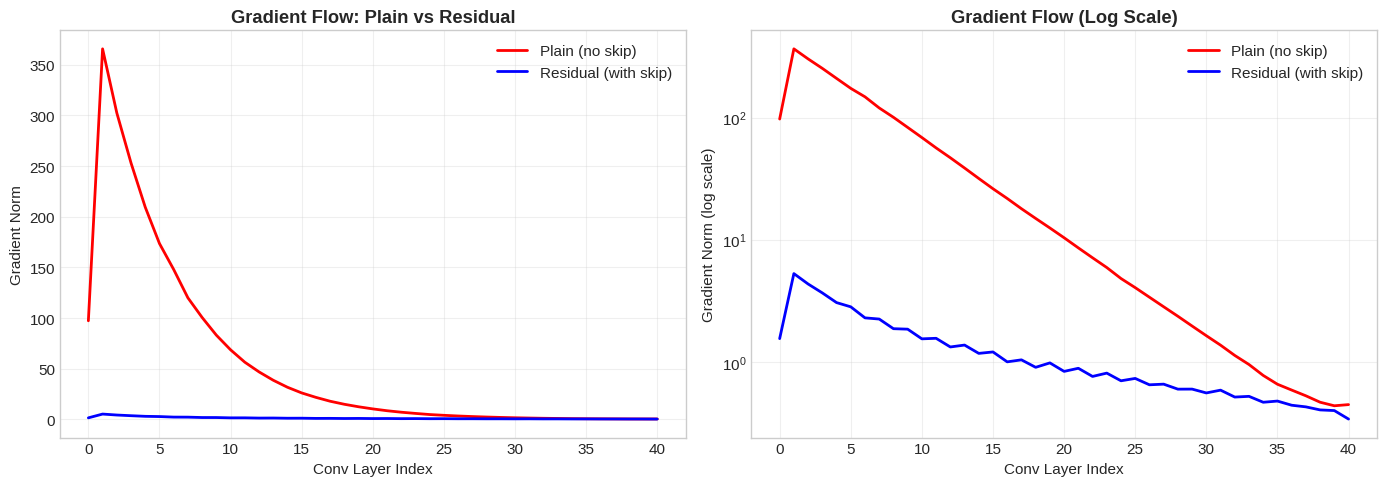


 Skip connections create a 'gradient highway'!
 Gradients flow directly through the identity mapping.


In [6]:
# ============================================================================
#                    GRADIENT FLOW IN RESNET
# ============================================================================

print("="*60)
print("       GRADIENT FLOW: PLAIN vs RESIDUAL")
print("="*60)

class PlainBlock(nn.Module):
    """Plain block WITHOUT skip connection."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        return out  # No skip connection!


class ResidualBlock(nn.Module):
    """Residual block WITH skip connection."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out + x)  # Skip connection!
        return out


def create_network(block_class, n_blocks):
    layers = [nn.Conv2d(3, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU()]
    for _ in range(n_blocks):
        layers.append(block_class(64))
    layers.extend([nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 10)])
    return nn.Sequential(*layers)


def measure_conv_gradients(model, x, target):
    """Measure gradients at conv layers."""
    model.zero_grad()
    output = model(x)
    loss = F.cross_entropy(output, target)
    loss.backward()

    gradients = []
    for module in model.modules():
        if isinstance(module, nn.Conv2d) and module.weight.grad is not None:
            gradients.append(module.weight.grad.norm().item())
    return gradients


# Compare gradient flow
n_blocks = 20
x = torch.randn(4, 3, 32, 32)
target = torch.randint(0, 10, (4,))

plain_net = create_network(PlainBlock, n_blocks)
res_net = create_network(ResidualBlock, n_blocks)

plain_grads = measure_conv_gradients(plain_net, x.clone(), target.clone())
res_grads = measure_conv_gradients(res_net, x.clone(), target.clone())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(plain_grads, 'r-', label='Plain (no skip)', linewidth=2)
axes[0].plot(res_grads, 'b-', label='Residual (with skip)', linewidth=2)
axes[0].set_xlabel('Conv Layer Index')
axes[0].set_ylabel('Gradient Norm')
axes[0].set_title('Gradient Flow: Plain vs Residual', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].semilogy(plain_grads, 'r-', label='Plain (no skip)', linewidth=2)
axes[1].semilogy(res_grads, 'b-', label='Residual (with skip)', linewidth=2)
axes[1].set_xlabel('Conv Layer Index')
axes[1].set_ylabel('Gradient Norm (log scale)')
axes[1].set_title('Gradient Flow (Log Scale)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Skip connections create a 'gradient highway'!")
print(" Gradients flow directly through the identity mapping.")

---

# Chapter 3: Advanced Building Blocks

## Modern Innovations in CNN Blocks

| Block | Key Innovation | Used In |
|-------|---------------|--------|
| SE Block | Channel attention | SENet, EfficientNet |
| MBConv | Depthwise separable + inverted residual | MobileNet, EfficientNet |
| ConvNeXt Block | Modernized ResNet | ConvNeXt |

In [7]:
# ============================================================================
#                    SQUEEZE-AND-EXCITATION BLOCK
# ============================================================================

print("="*60)
print("       SQUEEZE-AND-EXCITATION (SE) BLOCK")
print("="*60)

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation Block

    Learns to weight channels based on their importance:

        Input (C, H, W)
            ↓
        Global Avg Pool → (C, 1, 1)     <- "Squeeze"
            ↓
        FC (C → C/r)                    <- Reduce
            ↓
        ReLU
            ↓
        FC (C/r → C)                    <- Expand
            ↓
        Sigmoid → channel weights       <- "Excitation"
            ↓
        Input × weights                  <- Re-calibrate

    This lets the network learn which channels are important!
    """

    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()

        mid_channels = channels // reduction

        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, mid_channels, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid_channels, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.size()

        # Squeeze: Global average pooling
        y = self.squeeze(x).view(b, c)

        # Excitation: Learn channel weights
        y = self.excitation(y).view(b, c, 1, 1)

        # Re-calibrate: Scale channels
        return x * y.expand_as(x)


# Test SE block
se = SEBlock(64, reduction=16)
x = torch.randn(2, 64, 32, 32)
y = se(x)

print(f"\nSE Block:")
print(f"  Input:  {x.shape}")
print(f"  Output: {y.shape}")
print(f"  Parameters: {sum(p.numel() for p in se.parameters()):,}")
print(f"  (Only adds ~{100*sum(p.numel() for p in se.parameters())/(64*64*9):.1f}% params to a 3x3 conv!)")

       SQUEEZE-AND-EXCITATION (SE) BLOCK

SE Block:
  Input:  torch.Size([2, 64, 32, 32])
  Output: torch.Size([2, 64, 32, 32])
  Parameters: 512
  (Only adds ~1.4% params to a 3x3 conv!)


In [8]:
# ============================================================================
#                    MOBILE INVERTED BOTTLENECK (MBConv)
# ============================================================================

print("="*60)
print("       MOBILE INVERTED BOTTLENECK (MBConv)")
print("="*60)

class MBConv(nn.Module):
    """
    Mobile Inverted Bottleneck (from MobileNetV2, used in EfficientNet)

    "Inverted" because it EXPANDS then compresses (opposite of bottleneck):

        Input (C channels)
            ↓
        1x1 Conv (C → C*expand)        <- Expand channels
            ↓
        Depthwise 3x3 Conv             <- Spatial filtering (cheap!)
            ↓
        SE Block (optional)
            ↓
        1x1 Conv (C*expand → out)      <- Project back
            ↓
        + input (skip connection)

    Key innovations:
    - Depthwise separable convolutions (MobileNet)
    - Inverted residual (expand-depthwise-project)
    - Linear bottleneck (no ReLU after last 1x1)
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        expand_ratio: int = 6,
        stride: int = 1,
        se_ratio: float = 0.25
    ):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)
        mid_channels = in_channels * expand_ratio

        layers = []

        # Expansion (skip if expand_ratio == 1)
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, mid_channels, 1, bias=False),
                nn.BatchNorm2d(mid_channels),
                nn.SiLU(inplace=True)  # Swish activation
            ])

        # Depthwise convolution
        layers.extend([
            nn.Conv2d(mid_channels, mid_channels, 3, stride, 1,
                     groups=mid_channels, bias=False),  # groups=mid_channels makes it depthwise!
            nn.BatchNorm2d(mid_channels),
            nn.SiLU(inplace=True)
        ])

        # SE block
        if se_ratio > 0:
            se_channels = max(1, int(in_channels * se_ratio))
            layers.append(SEBlock(mid_channels, mid_channels // se_channels))

        # Projection (no activation - "linear bottleneck")
        layers.extend([
            nn.Conv2d(mid_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])

        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)


# Test MBConv
mbconv = MBConv(32, 32, expand_ratio=6, stride=1)
x = torch.randn(2, 32, 56, 56)
y = mbconv(x)

print(f"\nMBConv Block:")
print(f"  Input:  {x.shape}")
print(f"  Output: {y.shape}")
print(f"  Parameters: {sum(p.numel() for p in mbconv.parameters()):,}")

# Compare with standard conv
standard_conv = nn.Sequential(
    nn.Conv2d(32, 32, 3, 1, 1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, 1, 1),
    nn.BatchNorm2d(32)
)
standard_params = sum(p.numel() for p in standard_conv.parameters())

print(f"\nComparison:")
print(f"  Standard 2x conv block: {standard_params:,} params")
print(f"  MBConv block:           {sum(p.numel() for p in mbconv.parameters()):,} params")
print(f"\n Depthwise separable is much more efficient!")

       MOBILE INVERTED BOTTLENECK (MBConv)

MBConv Block:
  Input:  torch.Size([2, 32, 56, 56])
  Output: torch.Size([2, 32, 56, 56])
  Parameters: 17,920

Comparison:
  Standard 2x conv block: 18,624 params
  MBConv block:           17,920 params

 Depthwise separable is much more efficient!


---

# Chapter 4: EfficientNet - Compound Scaling

## The Problem: How to Scale Networks?

Three ways to make a network more powerful:
- **Width**: More channels per layer
- **Depth**: More layers
- **Resolution**: Larger input images

### EfficientNet's Solution: Compound Scaling

Scale all three together with a compound coefficient $\phi$:

$$\text{depth}: d = \alpha^\phi$$
$$\text{width}: w = \beta^\phi$$
$$\text{resolution}: r = \gamma^\phi$$

Where $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$ (FLOPS roughly double)

In [9]:
# ============================================================================
#                    EFFICIENTNET ARCHITECTURE
# ============================================================================

print("="*60)
print("              EFFICIENTNET")
print("="*60)

# EfficientNet-B0 baseline architecture
# (stage, expand_ratio, channels, layers, stride)
EFFICIENTNET_CONFIG = [
    # stage 1
    (1, 1, 16, 1, 1),
    # stage 2
    (2, 6, 24, 2, 2),
    # stage 3
    (3, 6, 40, 2, 2),
    # stage 4
    (4, 6, 80, 3, 2),
    # stage 5
    (5, 6, 112, 3, 1),
    # stage 6
    (6, 6, 192, 4, 2),
    # stage 7
    (7, 6, 320, 1, 1),
]

# Scaling coefficients for different variants
EFFICIENTNET_SCALES = {
    # (width_mult, depth_mult, resolution, dropout)
    'b0': (1.0, 1.0, 224, 0.2),
    'b1': (1.0, 1.1, 240, 0.2),
    'b2': (1.1, 1.2, 260, 0.3),
    'b3': (1.2, 1.4, 300, 0.3),
    'b4': (1.4, 1.8, 380, 0.4),
    'b5': (1.6, 2.2, 456, 0.4),
    'b6': (1.8, 2.6, 528, 0.5),
    'b7': (2.0, 3.1, 600, 0.5),
}

print("\nEfficientNet Scaling:")
print("="*60)
print(f"{'Variant':<10} {'Width':<10} {'Depth':<10} {'Resolution':<12} {'Dropout'}")
print("-"*60)
for name, (w, d, r, drop) in EFFICIENTNET_SCALES.items():
    print(f"{name.upper():<10} {w:<10.1f} {d:<10.1f} {r:<12} {drop}")

              EFFICIENTNET

EfficientNet Scaling:
Variant    Width      Depth      Resolution   Dropout
------------------------------------------------------------
B0         1.0        1.0        224          0.2
B1         1.0        1.1        240          0.2
B2         1.1        1.2        260          0.3
B3         1.2        1.4        300          0.3
B4         1.4        1.8        380          0.4
B5         1.6        2.2        456          0.4
B6         1.8        2.6        528          0.5
B7         2.0        3.1        600          0.5


In [10]:
# ============================================================================
#                    USING PRETRAINED EFFICIENTNET
# ============================================================================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

print("\nPretrained EfficientNet Models:")
print("="*60)

# Load models
eff_b0 = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
eff_b4 = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# Compare
models_info = [
    ('EfficientNet-B0', eff_b0, 224, 77.1),
    ('EfficientNet-B4', eff_b4, 380, 82.9),
]

print(f"{'Model':<20} {'Params':<15} {'Resolution':<12} {'Top-1 Acc'}")
print("-"*60)
for name, model, res, acc in models_info:
    params = count_params(model)
    print(f"{name:<20} {params:>12,}   {res}x{res}       {acc}%")

print("\n EfficientNet achieves better accuracy with fewer parameters!")


Pretrained EfficientNet Models:
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 136MB/s]


Model                Params          Resolution   Top-1 Acc
------------------------------------------------------------
EfficientNet-B0         5,288,548   224x224       77.1%
EfficientNet-B4        19,341,616   380x380       82.9%

 EfficientNet achieves better accuracy with fewer parameters!


---

# Chapter 5: Transfer Learning

## Standing on the Shoulders of Giants

Training from scratch requires:
- Millions of images
- Expensive GPU compute
- Careful hyperparameter tuning

**Transfer learning** uses pretrained models as a starting point!

### Two Approaches

| Approach | Freeze Backbone | Train Classifier | When to Use |
|----------|----------------|-----------------|-------------|
| **Feature Extraction** | Yes | Yes | Small dataset, similar domain |
| **Fine-Tuning** | No (or partial) | Yes | Larger dataset, different domain |

In [11]:
# ============================================================================
#                    TRANSFER LEARNING SETUP
# ============================================================================

print("="*60)
print("              TRANSFER LEARNING")
print("="*60)

def create_transfer_model(
    base_model: str = 'resnet18',
    num_classes: int = 10,
    freeze_backbone: bool = True,
    pretrained: bool = True
) -> nn.Module:
    """
    Create a model for transfer learning.

    Steps:
    1. Load pretrained model
    2. Replace classifier head
    3. Optionally freeze backbone
    """
    # Load pretrained model
    if base_model == 'resnet18':
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet18(weights=weights)
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)

    elif base_model == 'resnet50':
        weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        model = models.resnet50(weights=weights)
        num_features = model.fc.in_features
        model.fc = nn.Linear(num_features, num_classes)

    elif base_model == 'efficientnet_b0':
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        model = efficientnet_b0(weights=weights)
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, num_classes)

    else:
        raise ValueError(f"Unknown model: {base_model}")

    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        # Unfreeze classifier
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True

    return model


# Create models
print("\nFeature Extraction (frozen backbone):")
feature_model = create_transfer_model('resnet18', num_classes=10, freeze_backbone=True)

trainable = sum(p.numel() for p in feature_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in feature_model.parameters())
print(f"  Total params:     {total:,}")
print(f"  Trainable params: {trainable:,} ({100*trainable/total:.1f}%)")

print("\nFine-Tuning (all params trainable):")
finetune_model = create_transfer_model('resnet18', num_classes=10, freeze_backbone=False)

trainable = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in finetune_model.parameters())
print(f"  Total params:     {total:,}")
print(f"  Trainable params: {trainable:,} ({100*trainable/total:.1f}%)")

              TRANSFER LEARNING

Feature Extraction (frozen backbone):
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


  Total params:     11,181,642
  Trainable params: 5,130 (0.0%)

Fine-Tuning (all params trainable):
  Total params:     11,181,642
  Trainable params: 11,181,642 (100.0%)


In [12]:
# ============================================================================
#                    DATA PREPARATION FOR TRANSFER LEARNING
# ============================================================================

print("="*60)
print("       DATA PREPARATION FOR TRANSFER LEARNING")
print("="*60)

# ImageNet statistics (pretrained models expect these!)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms
train_transforms = transforms.Compose([
    transforms.Resize(256),                    # Resize smaller edge to 256
    transforms.RandomCrop(224),                # Random 224x224 crop
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation transforms (no augmentation!)
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),                # Center crop (deterministic)
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("\nKey points for transfer learning transforms:")
print("  1. Use ImageNet mean and std for normalization")
print("  2. Resize to expected input size (224 for most models)")
print("  3. Apply augmentation during training only")
print("  4. Use center crop for validation (reproducible)")

       DATA PREPARATION FOR TRANSFER LEARNING

Key points for transfer learning transforms:
  1. Use ImageNet mean and std for normalization
  2. Resize to expected input size (224 for most models)
  3. Apply augmentation during training only
  4. Use center crop for validation (reproducible)


In [13]:
# ============================================================================
#                    LOAD CIFAR-10 FOR TRANSFER LEARNING
# ============================================================================

# For transfer learning demo, we'll use CIFAR-10 resized to 224x224
# In practice, you'd use your own dataset

cifar_train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

cifar_val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Load datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=cifar_train_transforms
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=cifar_val_transforms
)

# Use subset for faster training (demo purposes)
train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\nDataset sizes:")
print(f"  Training: {len(train_subset)} samples")
print(f"  Test:     {len(test_subset)} samples")

100%|██████████| 170M/170M [00:03<00:00, 44.4MB/s]



Dataset sizes:
  Training: 5000 samples
  Test:     1000 samples


---

# Chapter 6: Fine-Tuning Strategies

## Advanced Techniques for Better Results

| Strategy | Description | When to Use |
|----------|-------------|-------------|
| **Gradual Unfreezing** | Unfreeze layers progressively | Medium-sized datasets |
| **Discriminative LR** | Lower LR for early layers | Always recommended |
| **Warm Restarts** | Cycle learning rate | Long training runs |

In [14]:
# ============================================================================
#                    DISCRIMINATIVE LEARNING RATES
# ============================================================================

print("="*60)
print("       DISCRIMINATIVE LEARNING RATES")
print("="*60)

def get_param_groups_with_discriminative_lr(
    model: nn.Module,
    base_lr: float = 1e-3,
    lr_decay: float = 0.1
) -> List[dict]:
    """
    Create parameter groups with discriminative learning rates.

    Earlier layers (pretrained features) get lower learning rates.
    Later layers (task-specific) get higher learning rates.

    For ResNet:
    - layer4: base_lr
    - layer3: base_lr * lr_decay
    - layer2: base_lr * lr_decay^2
    - layer1: base_lr * lr_decay^3
    - stem: base_lr * lr_decay^4
    """
    param_groups = []

    # For ResNet-style models
    layer_names = ['layer4', 'layer3', 'layer2', 'layer1', 'conv1', 'bn1']

    # Classifier gets base learning rate
    if hasattr(model, 'fc'):
        param_groups.append({
            'params': model.fc.parameters(),
            'lr': base_lr,
            'name': 'classifier'
        })

    # Earlier layers get lower learning rates
    for i, layer_name in enumerate(layer_names):
        if hasattr(model, layer_name):
            layer = getattr(model, layer_name)
            lr = base_lr * (lr_decay ** (i + 1))
            param_groups.append({
                'params': layer.parameters(),
                'lr': lr,
                'name': layer_name
            })

    return param_groups


# Example
model = create_transfer_model('resnet18', num_classes=10, freeze_backbone=False)
param_groups = get_param_groups_with_discriminative_lr(model, base_lr=1e-3, lr_decay=0.1)

print("\nDiscriminative Learning Rates:")
print(f"{'Layer':<15} {'Learning Rate':<15}")
print("-"*30)
for group in param_groups:
    print(f"{group['name']:<15} {group['lr']:.2e}")

print("\n Early layers learn more slowly (preserve pretrained features)")
print(" Later layers adapt more quickly to new task")

       DISCRIMINATIVE LEARNING RATES

Discriminative Learning Rates:
Layer           Learning Rate  
------------------------------
classifier      1.00e-03
layer4          1.00e-04
layer3          1.00e-05
layer2          1.00e-06
layer1          1.00e-07
conv1           1.00e-08
bn1             1.00e-09

 Early layers learn more slowly (preserve pretrained features)
 Later layers adapt more quickly to new task


In [15]:
# ============================================================================
#                    COMPLETE TRANSFER LEARNING TRAINING
# ============================================================================

def train_transfer_model(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int = 10,
    lr: float = 1e-3,
    device: str = 'cpu'
) -> dict:
    """
    Train a transfer learning model.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Only optimize trainable parameters
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                running_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_loss = running_loss / total
        val_acc = 100. * correct / total

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

    return history

In [16]:
# ============================================================================
#                    COMPARE APPROACHES
# ============================================================================

print("="*60)
print("       COMPARING TRANSFER LEARNING APPROACHES")
print("="*60)

# 1. Feature extraction (frozen backbone)
print("\n1. Feature Extraction (frozen backbone):")
feature_model = create_transfer_model('resnet18', 10, freeze_backbone=True)
feature_history = train_transfer_model(
    feature_model, train_loader, test_loader,
    epochs=5, lr=1e-3, device=device
)

# 2. Fine-tuning (all layers)
print("\n2. Fine-Tuning (all layers trainable):")
finetune_model = create_transfer_model('resnet18', 10, freeze_backbone=False)
finetune_history = train_transfer_model(
    finetune_model, train_loader, test_loader,
    epochs=5, lr=1e-4, device=device  # Lower LR for fine-tuning!
)

# 3. Training from scratch (for comparison)
print("\n3. Training from Scratch (no pretrained weights):")
scratch_model = create_transfer_model('resnet18', 10, freeze_backbone=False, pretrained=False)
scratch_history = train_transfer_model(
    scratch_model, train_loader, test_loader,
    epochs=5, lr=1e-3, device=device
)

       COMPARING TRANSFER LEARNING APPROACHES

1. Feature Extraction (frozen backbone):
Epoch   1/5 | Train: 54.0% | Val: 69.2%
Epoch   2/5 | Train: 73.3% | Val: 75.1%
Epoch   3/5 | Train: 76.0% | Val: 73.7%
Epoch   4/5 | Train: 77.8% | Val: 76.2%
Epoch   5/5 | Train: 78.5% | Val: 76.7%

2. Fine-Tuning (all layers trainable):
Epoch   1/5 | Train: 76.0% | Val: 87.3%
Epoch   2/5 | Train: 92.5% | Val: 87.8%
Epoch   3/5 | Train: 96.9% | Val: 89.2%
Epoch   4/5 | Train: 98.5% | Val: 90.5%
Epoch   5/5 | Train: 99.4% | Val: 90.3%

3. Training from Scratch (no pretrained weights):
Epoch   1/5 | Train: 28.2% | Val: 36.2%
Epoch   2/5 | Train: 37.3% | Val: 39.9%
Epoch   3/5 | Train: 44.5% | Val: 42.5%
Epoch   4/5 | Train: 52.2% | Val: 52.5%
Epoch   5/5 | Train: 59.6% | Val: 56.6%


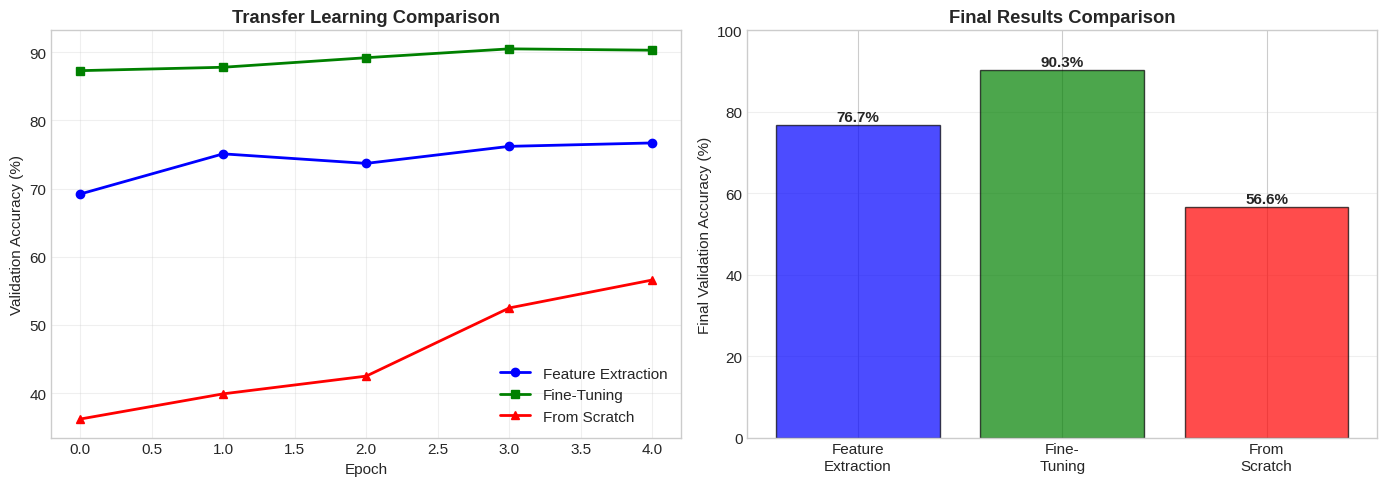


 Key Insights:
 - Transfer learning converges much faster
 - Pretrained features are highly valuable
 - Fine-tuning often gives best results with enough data


In [17]:
# ============================================================================
#                    VISUALIZE COMPARISON
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.plot(feature_history['val_acc'], 'b-', linewidth=2, marker='o',
         label='Feature Extraction')
ax1.plot(finetune_history['val_acc'], 'g-', linewidth=2, marker='s',
         label='Fine-Tuning')
ax1.plot(scratch_history['val_acc'], 'r-', linewidth=2, marker='^',
         label='From Scratch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Accuracy (%)')
ax1.set_title('Transfer Learning Comparison', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Final results bar chart
final_accs = [
    feature_history['val_acc'][-1],
    finetune_history['val_acc'][-1],
    scratch_history['val_acc'][-1]
]
names = ['Feature\nExtraction', 'Fine-\nTuning', 'From\nScratch']
colors = ['blue', 'green', 'red']

bars = ax2.bar(names, final_accs, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Final Validation Accuracy (%)')
ax2.set_title('Final Results Comparison', fontweight='bold')

for bar, acc in zip(bars, final_accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')

ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Key Insights:")
print(" - Transfer learning converges much faster")
print(" - Pretrained features are highly valuable")
print(" - Fine-tuning often gives best results with enough data")

---

# Summary: Modern CNN Best Practices

## Architecture Insights

| Innovation | Benefit | Used In |
|------------|---------|--------|
| Skip Connections | Enable very deep networks | ResNet, DenseNet |
| Bottleneck | Reduce parameters | ResNet-50+ |
| SE Blocks | Channel attention | SENet, EfficientNet |
| MBConv | Efficient mobile blocks | MobileNet, EfficientNet |
| Compound Scaling | Balanced scaling | EfficientNet |

## Transfer Learning Guidelines

| Scenario | Recommended Approach |
|----------|---------------------|
| Small dataset, similar domain | Feature extraction (freeze backbone) |
| Medium dataset | Fine-tune top layers |
| Large dataset, different domain | Fine-tune all with discriminative LR |

## Next Steps

- **Part 3**: Vision Transformers (ViT, CLIP, DINOv2, SAM)

---

*"Standing on the shoulders of giants."* - Isaac Newton

**Happy Learning!**

In [18]:
# ============================================================================
#                    MODERN CNN CHEAT SHEET
# ============================================================================

print("="*70)
print("                MODERN CNN CHEAT SHEET")
print("="*70)

cheat_sheet = """
RESIDUAL BLOCKS
---------------
Basic Block (ResNet-18/34):
  x -> Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> (+x) -> ReLU

Bottleneck Block (ResNet-50+):
  x -> Conv1x1 -> BN -> ReLU -> Conv3x3 -> BN -> ReLU -> Conv1x1 -> BN -> (+x) -> ReLU

SE BLOCK
--------
x -> GlobalAvgPool -> FC(C/r) -> ReLU -> FC(C) -> Sigmoid -> x * weights

MBCONV (EfficientNet)
--------------------
x -> Conv1x1(expand) -> DepthwiseConv3x3 -> SE -> Conv1x1(project) -> (+x)

PRETRAINED MODELS (torchvision)
-------------------------------
from torchvision.models import resnet50, ResNet50_Weights
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Modify classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

IMAGENET NORMALIZATION
----------------------
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transforms.Normalize(mean, std)

TRANSFER LEARNING STRATEGIES
---------------------------
1. Feature Extraction: Freeze all but classifier
2. Fine-Tuning: Lower LR, unfreeze gradually
3. Discriminative LR: Lower LR for early layers

MODEL SELECTION
---------------
Small/Mobile: MobileNetV3, EfficientNet-B0
Balanced: ResNet-50, EfficientNet-B4
Maximum accuracy: EfficientNet-B7, ConvNeXt-XL
"""
print(cheat_sheet)

                MODERN CNN CHEAT SHEET

RESIDUAL BLOCKS
---------------
Basic Block (ResNet-18/34):
  x -> Conv3x3 -> BN -> ReLU -> Conv3x3 -> BN -> (+x) -> ReLU

Bottleneck Block (ResNet-50+):
  x -> Conv1x1 -> BN -> ReLU -> Conv3x3 -> BN -> ReLU -> Conv1x1 -> BN -> (+x) -> ReLU

SE BLOCK
--------
x -> GlobalAvgPool -> FC(C/r) -> ReLU -> FC(C) -> Sigmoid -> x * weights

MBCONV (EfficientNet)
--------------------
x -> Conv1x1(expand) -> DepthwiseConv3x3 -> SE -> Conv1x1(project) -> (+x)

PRETRAINED MODELS (torchvision)
-------------------------------
from torchvision.models import resnet50, ResNet50_Weights
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# Modify classifier
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

IMAGENET NORMALIZATION
----------------------
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.2